# Pipelines

ce notebook sert pour tester le backend des pipelines

# Initialisation

In [1]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


## Imports Librairies

In [2]:
import os
from tqdm import tqdm
import glob
import numpy as np
from PIL import Image
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


"""import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
"""

'import warnings\nfrom sklearn.exceptions import ConvergenceWarning\nwarnings.filterwarnings("ignore", category=ConvergenceWarning)\n'

## Configs

### Variables Environnement

In [3]:
root_dir = '../../data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/'

## Definitions

### Fonctions

In [4]:
def load_paths_data_raw(root_dir):
    image_paths = []
    mask_paths = []
    labels = []

    for label in os.listdir(root_dir):
        class_img_dir = os.path.join(root_dir, label, 'images')
        class_mask_dir = os.path.join(root_dir, label, 'masks')
        if os.path.isdir(class_img_dir):
            for img_path in glob.glob(os.path.join(class_img_dir, '*.png')):
                filename = os.path.basename(img_path)
                mask_path = os.path.join(class_mask_dir, filename)
                if os.path.exists(mask_path):
                    image_paths.append(img_path)
                    mask_paths.append(mask_path)
                    labels.append(label.lower())

    return image_paths, mask_paths, labels

### Transformeurs

#### Image Loader

In [5]:
# Transformer pour charger et prétraiter les images
class ImageLoader(BaseEstimator, TransformerMixin):
    def __init__(self, img_size=(128, 128)):
        self.img_size = img_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        print(f"\nChargement de {len(X)} images...")
        images = []
        for path in tqdm(X, desc="Images"):
            img = Image.open(path).convert('L')  # PAS de resize ici
            images.append(img)
        print("Chargement terminé.\n")
        return images  # Liste d'images PIL

# Exemple d’utilisation
# Supposons que X contienne les chemins d’images et y les labels
# X = ['data/img1.png', 'data/img2.png', ...]
# y = [0, 1, 0, 1, ...]

#### Image Resizer

In [6]:
class ImageResizer(BaseEstimator, TransformerMixin):
    def __init__(self, img_size=(256, 256)):
        self.img_size = img_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        print(f"\nRedimensionnement de {len(X)} images en {self.img_size} ...")
        resized = []
        for img in tqdm(X, desc="Redimensionnement"):
            if isinstance(img, np.ndarray):
                img = Image.fromarray(img)
            img_resized = img.resize(self.img_size)
            resized.append(np.array(img_resized))
        print("Redimensionnement terminé.\n")
        return np.array(resized)

#### Image Masker

In [7]:
class ImageMasker(BaseEstimator, TransformerMixin):
    def __init__(self, mask_paths):
        self.mask_paths = mask_paths

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        print(f"\nApplication des masques sur {len(X)} images ...")
        masked = []
        for img, mask_path in tqdm(zip(X, self.mask_paths), desc="Masquage", total=len(X)):
            mask = Image.open(mask_path).convert('L').resize(img.shape[::-1])
            mask_arr = np.array(mask) > 0  # binaire
            masked.append(img * mask_arr)
        print("Masquage terminé.\n")
        return np.array(masked)

#### Image Flattener

In [8]:
class ImageFlattener(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        print(f"\nAplatissement de {X.shape[0]} images ...")
        n_samples = X.shape[0]
        X_flat = []
        for img in tqdm(X, desc="Aplatissement"):
            X_flat.append(img.flatten())
        X_flat = np.array(X_flat)
        print("Aplatissement terminé.\n")
        return X_flat

In [9]:
class VisualizeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_samples=5, prefix="step"):
        self.n_samples = n_samples
        self.prefix = prefix

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        for i in range(min(self.n_samples, len(X))):
            plt.figure()
            if hasattr(X[i], "shape") and len(X[i].shape) == 2:
                plt.imshow(X[i], cmap='gray')
            else:
                plt.plot(X[i])
            plt.title(f"{self.prefix} - Sample {i}")
            plt.axis('off')
            plt.show()
        return X

In [10]:
class SaveTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, save_dir="outputs", prefix="features"):
        self.save_dir = save_dir
        self.prefix = prefix
        os.makedirs(self.save_dir, exist_ok=True)

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        path = os.path.join(self.save_dir, f"{self.prefix}.npy")
        np.save(path, X)
        print(f"Features sauvegardées dans {path}")
        return X

# Main

## Chargement Paths

## Execution Pipeline

In [11]:
X, masks, y = load_paths_data_raw(root_dir)

In [12]:
print(f"Nombre d'images: {len(X)}")
print(f"Labels uniques: {set(y)}")


Nombre d'images: 21165
Labels uniques: {'lung_opacity', 'viral pneumonia', 'covid', 'normal'}


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 16932, Test size: 4233


In [14]:
def get_transformer_class(class_name):
    # Cherche la classe dans le scope global
    return globals()[class_name]

# Exemple d'utilisation avec un JSON de config
import json

with open("pipeline_config.json") as f:
    config = json.load(f)

pipeline_name = config.get("name", "pipeline")
steps = []
for step in config["steps"]:
    cls = get_transformer_class(step["class"])
    params = step["params"]
    if "mask_paths" in params and params["mask_paths"] == "masks":
        params["mask_paths"] = masks
    steps.append((step["name"], cls(**params)))

pipeline = Pipeline(steps, verbose=True)


Chargement de 16932 images...


Images: 100%|██████████| 16932/16932 [00:19<00:00, 873.00it/s]


Chargement terminé.

[Pipeline] ........ (step 1 of 7) Processing img_loader, total=  19.4s

Redimensionnement de 16932 images en [256, 256] ...


Redimensionnement: 100%|██████████| 16932/16932 [00:08<00:00, 1928.77it/s]


Redimensionnement terminé.

[Pipeline] ....... (step 2 of 7) Processing img_resizer, total=   9.2s

Application des masques sur 16932 images ...


Masquage: 100%|██████████| 16932/16932 [00:08<00:00, 2095.31it/s]


Masquage terminé.

[Pipeline] ........ (step 3 of 7) Processing img_masker, total=   8.5s

Aplatissement de 16932 images ...


Aplatissement: 100%|██████████| 16932/16932 [00:00<00:00, 42011.94it/s]


Aplatissement terminé.

[Pipeline] ....... (step 4 of 7) Processing img_flatten, total=   0.9s
Features sauvegardées dans outputs\flattened.npy
[Pipeline] ..... (step 5 of 7) Processing save_features, total=   6.9s


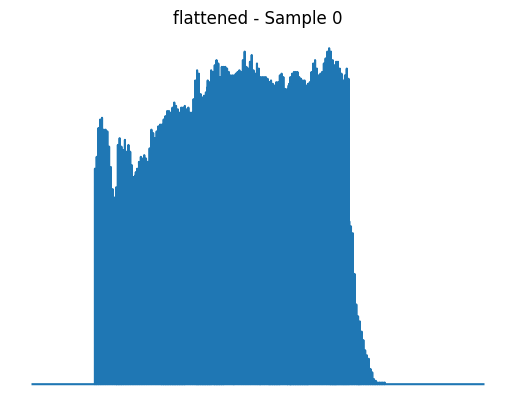

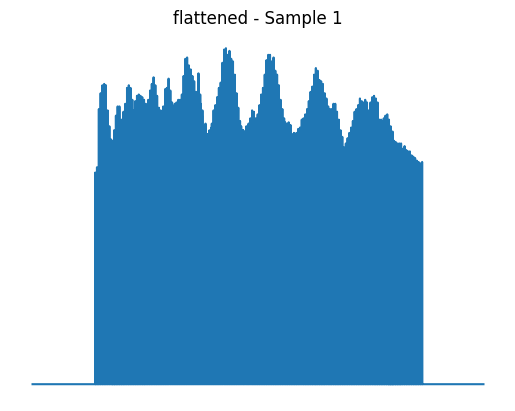

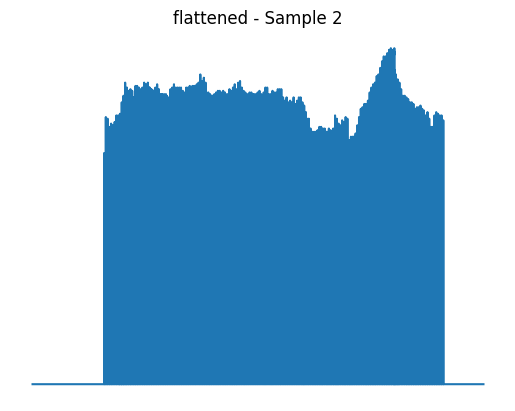

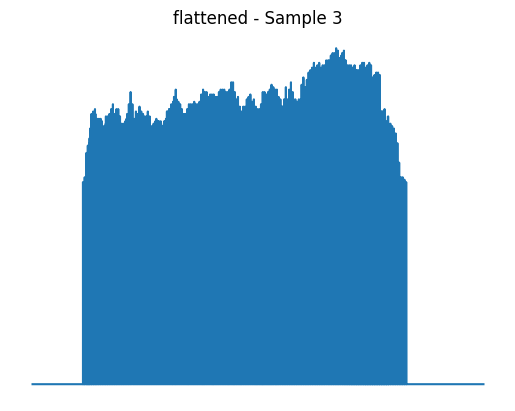

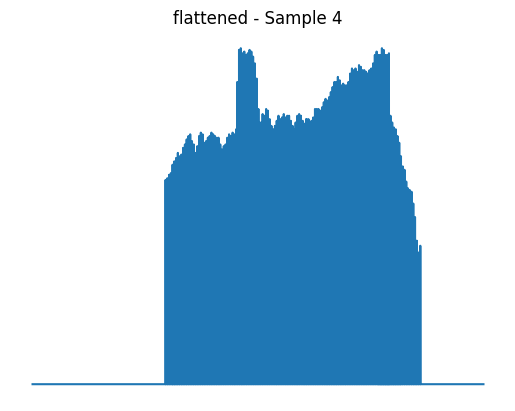

[Pipeline]  (step 6 of 7) Processing visualize_features, total=   0.3s


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 20.2min finished


[Pipeline] ............... (step 7 of 7) Processing clf, total=20.3min

Chargement de 4233 images...


Images: 100%|██████████| 4233/4233 [00:05<00:00, 781.94it/s]


Chargement terminé.


Redimensionnement de 4233 images en [256, 256] ...


...

Redimensionnement terminé.


Application des masques sur 4233 images ...


Masquage: 100%|██████████| 4233/4233 [00:01<00:00, 2351.34it/s]


Masquage terminé.


Aplatissement de 4233 images ...


Aplatissement: 100%|██████████| 4233/4233 [00:00<00:00, 43638.91it/s]


Aplatissement terminé.

Features sauvegardées dans outputs\flattened.npy


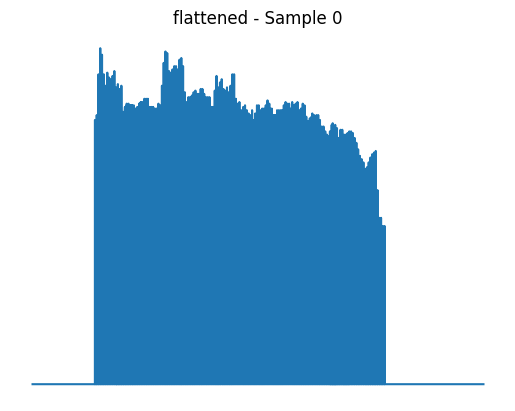

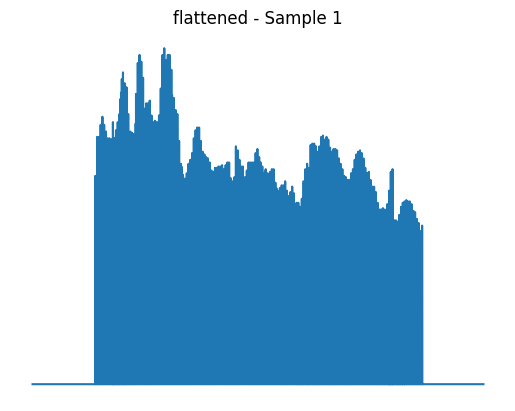

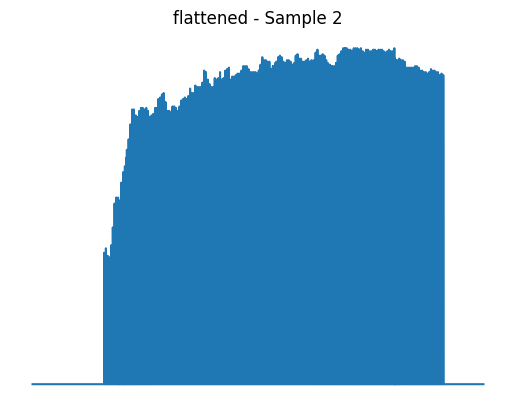

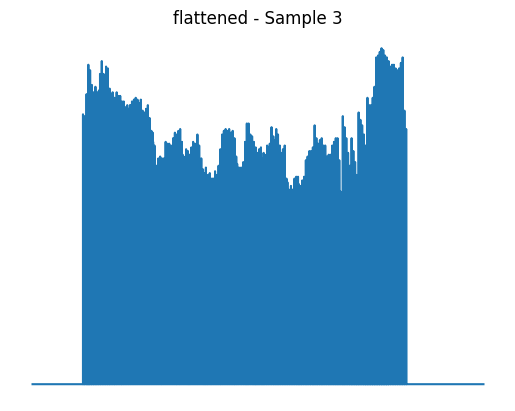

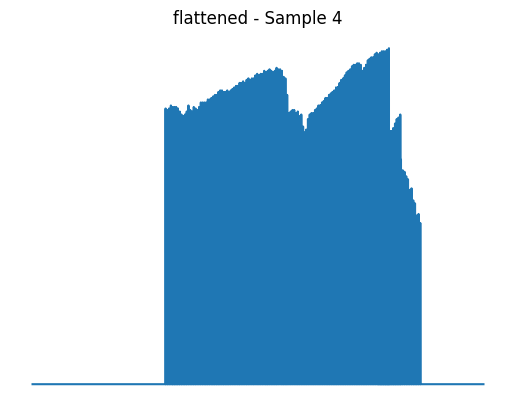


Chargement de 4233 images...


Images: 100%|██████████| 4233/4233 [00:04<00:00, 911.27it/s]


Chargement terminé.


Redimensionnement de 4233 images en [256, 256] ...


Redimensionnement: 100%|██████████| 4233/4233 [00:02<00:00, 1940.65it/s]


Redimensionnement terminé.


Application des masques sur 4233 images ...


Masquage: 100%|██████████| 4233/4233 [00:01<00:00, 2364.08it/s]


Masquage terminé.


Aplatissement de 4233 images ...


Aplatissement: 100%|██████████| 4233/4233 [00:00<00:00, 43639.33it/s]


Aplatissement terminé.

Features sauvegardées dans outputs\flattened.npy


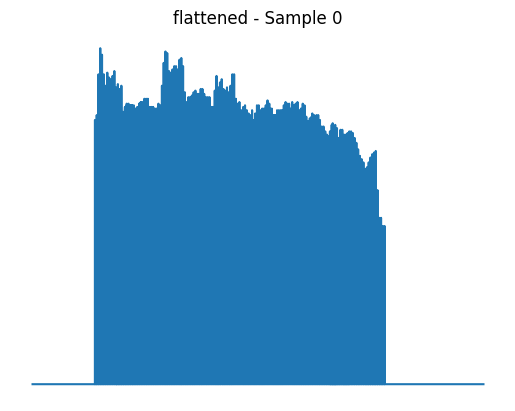

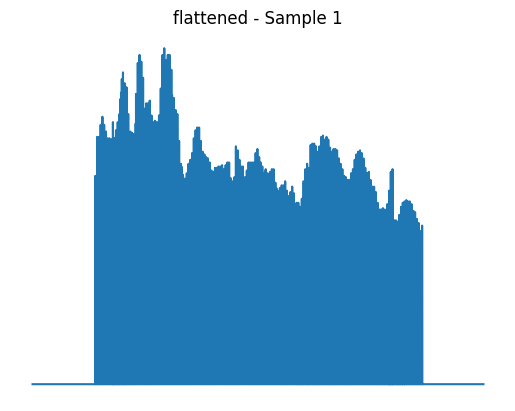

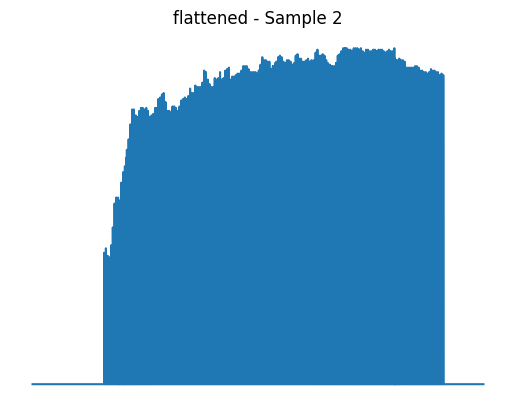

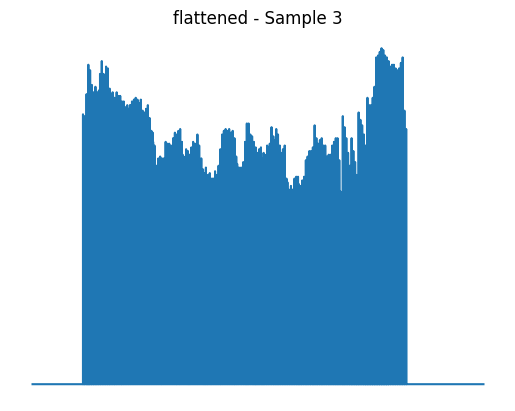

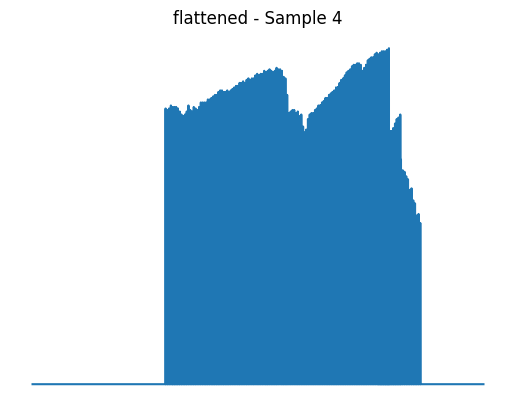

Accuracy: 0.42830144105835105

Classification report :
                 precision    recall  f1-score   support

          covid       0.20      0.21      0.20       701
   lung_opacity       0.38      0.38      0.38      1246
         normal       0.56      0.57      0.57      2024
viral pneumonia       0.21      0.17      0.19       262

       accuracy                           0.43      4233
      macro avg       0.34      0.33      0.33      4233
   weighted avg       0.43      0.43      0.43      4233


Matrice de confusion :
[[ 147  217  299   38]
 [ 217  468  507   54]
 [ 323  471 1154   76]
 [  56   77   85   44]]


In [15]:
pipeline.fit(X_train, y_train)

# ... entraînement du pipeline ...
y_pred = pipeline.predict(X_test)

print("Accuracy:", pipeline.score(X_test, y_test))
print("\nClassification report :")
print(classification_report(y_test, y_pred))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

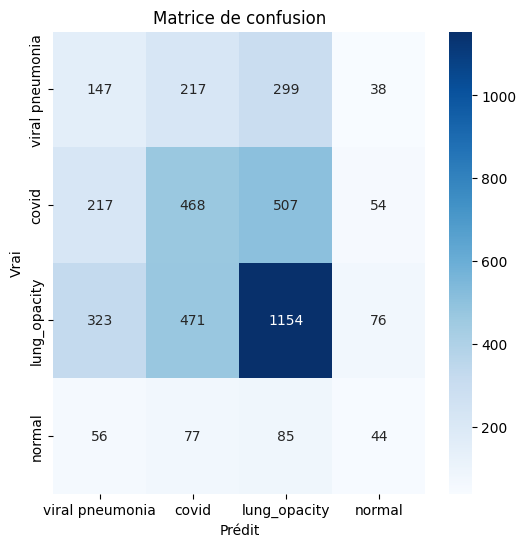

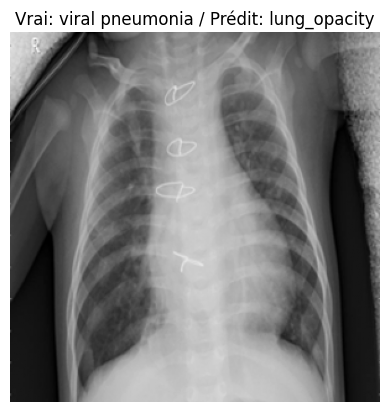

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matrice de confusion visuelle
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion')
plt.show()

# Afficher quelques images test avec prédiction et vrai label
for i in range(1):
    img = Image.open(X_test[i])
    plt.imshow(img, cmap='gray')
    plt.title(f"Vrai: {y_test[i]} / Prédit: {y_pred[i]}")
    plt.axis('off')
    plt.show()

In [17]:
n_iter = pipeline.named_steps["clf"].n_iter_
print(f"Nombre d'itérations effectuées par le classifieur : {n_iter[0]} (sur max_iter={pipeline.named_steps['clf'].max_iter})")

Nombre d'itérations effectuées par le classifieur : 709 (sur max_iter=2000)
